## Install Python Libraries

Start by running the following cell if needed to install required libraries:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch import softmax
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix
from datasets import load_from_disk
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import re
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false" # Avoids warning from tokenizer when using num_workers > 0 in DataLoader

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cpu.


# Encoder-only Transformer for Text Sentiment Classification

## 1. Data

### 1.1 Load the IMDB dataset

We will use the IMDB dataset for sentiment classification. The dataset consists of 50,000 movie reviews, each labeled as positive or negative. We will use 25k reviews for training, 5k for validation, and 20k for testing.

In [3]:
# Constants
SEED = 420
VAL_SIZE = 0.2

# Load IMDB dataset
dataset_train = load_from_disk("imdb_train")
dataset_test = load_from_disk("imdb_test")

# Split test into test and validation
dataset_test = dataset_test.train_test_split(test_size=1-VAL_SIZE, seed=SEED)
dataset_test, dataset_val = dataset_test["test"], dataset_test["train"]

print(f"Train size: {len(dataset_train)}")
print(f"Validation size: {len(dataset_val)}")
print(f"Test size: {len(dataset_test)}")

Train size: 25000
Validation size: 5000
Test size: 20000


### 1.2 Preprocess the data

We remove HTML tags, special characters, and convert the text to lowercase.

In [4]:
def remove_html_tags(text):
    # Remove HTML tags
    return re.sub(r'<[^>]*>', '', text)

def remove_special_characters(text):
    # Remove special characters except for ,.!? and space
    return re.sub(r'[^a-zA-Z0-9.,!? ]', '', text)

def to_lowercase(text):
    # Convert text to lowercase
    return text.lower()

def preprocess_text(text):
    # Apply all preprocessing steps to the text
    text = remove_html_tags(text)
    text = remove_special_characters(text)
    text = to_lowercase(text)
    return text

def preprocess_batch(examples):
    # Apply preprocessing to all texts in the batch
    examples["text"] = [preprocess_text(text) for text in examples["text"]]
    return examples

# Preprocess the dataset
dataset_train = dataset_train.map(preprocess_batch, batched=True)
dataset_val = dataset_val.map(preprocess_batch, batched=True)
dataset_test = dataset_test.map(preprocess_batch, batched=True)

### 1.3 Tokenization

We use a simple word-level tokenizer to tokenize the text data. We use three special tokens: `[PAD]`, `[UNK]` and `[CLS]`. The `[PAD]` token will be used to pad the input sequences to the same length. The `[UNK]` token is used to represent out-of-vocabulary words (rare words). When classifying text, we will prepend the `[CLS]` token to the input sequence and use its output as the representation of the whole sequence.

To reduce the vocabulary size, we only keep words appearing at least `MIN_FREQUENCY` times in the training set.

In [5]:
# Special tokens (padding, unknown, classification)
PAD_TOKEN = "[PAD]"
UNK_TOKEN = "[UNK]"
CLS_TOKEN = "[CLS]"
MIN_FREQUENCY = 10
VOCAB_SIZE = 10000

# Tokenizer setup
tokenizer = Tokenizer(WordLevel(unk_token=UNK_TOKEN))
tokenizer.pre_tokenizer = Whitespace() # Split on whitespace

# Train tokenizer on the training set
trainer = WordLevelTrainer(special_tokens=[PAD_TOKEN, UNK_TOKEN, CLS_TOKEN], min_frequency=MIN_FREQUENCY, vocab_size=VOCAB_SIZE)
tokenizer.train_from_iterator(dataset_train["text"], trainer)

We test the tokenizer on a few examples to verify that it works as expected.

In [6]:
for idx in range(5):
    example = dataset_train[idx]
    original_text = example["text"]
    tokenized_text = tokenizer.encode(example["text"])
    decoded_text = tokenizer.decode(tokenized_text.ids, skip_special_tokens=False)

    print(f"Original text: {original_text}")
    print(f"Tokenized text (tokens): {tokenized_text.tokens}")
    print(f"Tokenized text (IDs): {tokenized_text.ids}")
    print(f"Decoded text: {decoded_text}")
    print()

Original text: i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered controversial i really had to see this for myself.the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life. in particular she wants to focus her attentions to making some sort of documentary on what the average swede thought about certain political issues such as the vietnam war and race issues in the united states. in between asking politicians and ordinary denizens of stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.what kills me about i am curiousyellow is that 40 years ago, this was considered pornographic. really, the sex and nudity scenes are few and far between, even then its no

We plot the distribution of the sequence lengths in the training set. Later, we can use this to determine the maximum sequence length to use.

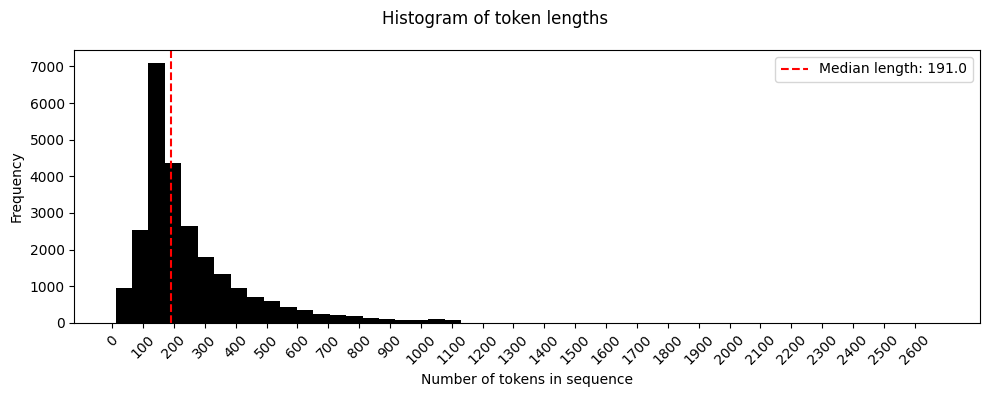

In [7]:
# Histogram of token lengths
token_lengths = [len(tokenizer.encode(text).ids) for text in dataset_train["text"]]
median_length = np.median(token_lengths)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=50, color="black")
ax.set_xticks(np.arange(0, np.max(token_lengths) + 1, 100))
ax.tick_params(axis="x", labelrotation=45)
ax.set_xlabel("Number of tokens in sequence")
ax.set_ylabel("Frequency")
ax.axvline(median_length, color="red", linestyle="--", label=f"Median length: {median_length}")
ax.legend()
fig.suptitle("Histogram of token lengths")
fig.tight_layout()
plt.show()

### 1.4 Dataset and Data Loaders

To deal with sequences of different lengths, we implement a simple `IMDBDataset` class that pads the sequences to the same length using the `[PAD]` token, or truncates them if they exceed the maximum sequence length. We also prepend the `[CLS]` token to the input sequences.

In [8]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length, pad_idx, cls_idx):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.cls_idx = cls_idx # TODO: Check if this makes sense

    def __len__(self):
        return len(self.texts)

    # https://www.huggingface.co/docs/tokenizers/python/latest/api/reference.html#tokenizer
    # https://www.huggingface.co/docs/tokenizers/python/latest/api/reference.html#tokenizers.Encoding
    def __getitem__(self, idx):
        # 1.1 Task 1:
        text = f"[CLS]{ self.texts[idx]}"
        tokenized_review = self.tokenizer.encode(text)
        ids = tokenized_review.ids

        # truncated
        ids = ids[:self.max_length]

        # add more padding if too short
        length_needed_padding = self.max_length - len(ids)
        ids += [self.pad_idx] * length_needed_padding

        # grab sentiment
        sentiment_label = self.labels[idx]
        return tuple([torch.tensor(ids, dtype = torch.long), torch.tensor(sentiment_label, dtype = torch.long)])

We create some constants:

- `MAX_LENGTH`: the maximum sequence length
- `PAD_ID`: the ID of the `[PAD]` token
- `CLS_ID`: the ID of the `[CLS]` token
- `BATCH_SIZE`: the batch size
- `NUM_WORKERS`: the number of workers for data loading (set this to 0 if you are encountering issues with the DataLoader)

We also create the training and testing datasets and data loaders.

In [9]:
# Constants
MAX_LENGTH = 256
PAD_ID = tokenizer.token_to_id(PAD_TOKEN)
CLS_ID = tokenizer.token_to_id(CLS_TOKEN)
BATCH_SIZE = 64
NUM_WORKERS = 4

In [10]:
# Dataset instances
train_dataset = IMDBDataset(dataset_train["text"], dataset_train["label"], tokenizer, MAX_LENGTH, PAD_ID, CLS_ID)
val_dataset = IMDBDataset(dataset_val["text"], dataset_val["label"], tokenizer, MAX_LENGTH, PAD_ID, CLS_ID)
test_dataset = IMDBDataset(dataset_test["text"], dataset_test["label"], tokenizer, MAX_LENGTH, PAD_ID, CLS_ID)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

## 2. Model

### 2.1 Training Loop

We define a simple train function that takes `model` and trains it for `num_epochs` on `train_loader`. We give the `criterion` (loss function) and `optimizer` as arguments to the function. The train function also needs to know `pad_id`, the ID of the `[PAD]` token so we can generate the attention mask making sure the model does not attend to the padding tokens. After each epoch, we evaluate the model on `val_loader`.

In [11]:
def create_mask(sequences, pad_id):
    """
    Input shape of token sequences: (batch_size, seq_length)
    Output shape: (batch_size, seq_length) boolean mask with True where the padding tokens are located
    """
    # 1.1. 2

    # where 0 make to True, rest is False

    # i tried this but we need torch array
    # return np.where(np.array(sequences) == pad_id, True, False)
    return (sequences == pad_id)

In [ ]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, pad_id):
    train_info = {
        "losses" : [],
        "accuracy" : []
    }

    val_info = {
        "losses" : [],
        "accuracy" : []
    }

    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        correct, total = 0, 0
        for sequences, labels in (pbar := tqdm(train_loader)):
            labels = labels.float()
            optimizer.zero_grad()
            attention_mask = create_mask(sequences, pad_id)
            outputs = model(sequences, mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)  # Clip gradients for stability
            optimizer.step()
            train_losses.append(loss.item())
            correct += ((outputs > 0.5) == labels).sum().item()
            total += labels.size(0)
            pbar.set_description(f"Epoch {epoch+1}, Train Loss: {np.mean(train_losses):.4f}, Train Acc.: {correct / total:.4f}")

        train_info["losses"].append(np.mean(train_losses))
        train_info["accuracy"].append(correct / total)

        # Validation
        model.eval()
        val_losses = []
        correct, total = 0, 0
        with torch.no_grad():
            for sequences, labels in tqdm(val_loader):
                labels = labels.float()
                attention_mask = create_mask(sequences, pad_id)
                outputs = model(sequences, mask=attention_mask)
                loss = criterion(outputs, labels)
                val_losses.append(loss.item())
                correct += ((outputs > 0.5) == labels).sum().item()
                total += labels.size(0)
        print(f"Epoch {epoch+1}, Val Loss: {np.mean(val_losses):.4f}, Val Acc.: {correct / total:.4f}")

        val_info["losses"].append(np.mean(val_losses))
        val_info["accuracy"].append(correct / total)

    return train_info, val_info

### 2.2 Multi-Head Attention

We implement the multi-head attention mechanism. The multi-head attention mechanism consists of `num_heads` independent attention mechanisms. We concatenate the outputs of the different heads and project them back to the model's dimension. We use the scaled dot-product attention mechanism.

$MhSa[X] = \Omega_c[Sa_1[X]^T, Sa_2[X]^T, ..., Sa_H[X]^T]^T$

In [ ]:
class MultiheadAttention(nn.Module):
    def __init__(self, dim, num_heads, dropout):
        """
        Multihead attention module.
        Args:
            dim: Dimension of the input vectors
            num_heads: Number of attention heads
            dropout: Dropout rate for attention scores (default: 0.1)
        """
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads

        assert dim % num_heads == 0, f"Dimension {dim} must be divisible by num_heads {num_heads}"

        self.head_dim = dim // num_heads

        # self.query = bias_v.T + omega_v * x
        self.query = nn.Linear(in_features = dim, out_features= dim)

        # self.key = bias_q.T + omega_q tput x
        self.key = nn.Linear(in_features = dim, out_features= dim)

        # self.value = bias_k.T + omega_k * x
        self.value = nn.Linear(in_features = dim, out_features= dim)

        # omega_c[sa1[x^t], ... sa_h[x]^T]^T
        self.out_proj = nn.Linear(in_features = dim, out_features= dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, key_padding_mask):
        batch_size, query_length, _selfdim = query.shape

        query = self.query(query)
        key = self.key(key)
        value = self.value(value)

        # ok now we need to project into different heads, so we reshape
        # B,T,D -> B,T,H, head_dim
        # so now each head computes parallel since we split it per head_dim
        query = query.view(batch_size, query_length, self.num_heads, self.head_dim).transpose(1, 2)
        key = key.view(batch_size, query_length, self.num_heads, self.head_dim).transpose(1, 2)
        value = value.view(batch_size, query_length, self.num_heads, self.head_dim).transpose(1, 2)

        attention_score = torch.matmul(query, key.transpose(-2,-1)) / np.sqrt(self.head_dim)

        # ok set masked positions to inf
        key_padding_mask = key_padding_mask.unsqueeze(1).unsqueeze(2) # match dimensions
        attention_score = attention_score.masked_fill(key_padding_mask, float("-inf"))

        attention_output = softmax(attention_score, dim=-1)
        attention_output = self.dropout(attention_output)

        attention_concat = torch.matmul(attention_output, value)

        concact_heads = attention_concat.transpose(1,2).contiguous().view(batch_size, query_length, self.dim)

        return self.out_proj(concact_heads)

### 2.3 Encoder Block

We implement the encoder block, which consists of our multi-head attention layer followed by a feedforward neural network. We also add residual connections and layer normalizations as specified in the project description.

In [14]:
class MLPBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim, 4*dim)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(4*dim, dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class EncoderBlock(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.1):
        super().__init__()

        self.ln1 = nn.LayerNorm(dim)
        # multihead, buildt in dropout
        self.mh1 = MultiheadAttention(
            dim=dim, num_heads=num_heads, dropout=dropout
        )

        self.ln2 = nn.LayerNorm(dim)
        # mlp, buildt in dropout
        self.mlpblock = MLPBlock(dim, dropout=dropout)


    def forward(self, x, mask=None):
        x_l1 = self.ln1(x)
        x_l1 = self.mh1(x_l1, x_l1, x_l1, mask)
        x_l1 += x

        x_l2 = self.ln2(x_l1)
        x_l2 = self.mlpblock(x_l2)
        x_l2 += x_l1
        return x_l2

### 2.4 Model Specification

We specify our classifier model, which consists of an embedding layer, followed by `num_layers` encoder blocks. We use a linear layer to project the output of the last encoder block and apply sigmoid activation to get the final output.

We also define the positional encoding, which is added to the input embeddings to give the model information about the position of the tokens in the sequence.

In [15]:
class PositionalEncoding(nn.Module):
    """
    Positional encoding module: adds positional information to the input embeddings.
    """
    def __init__(self, embed_size, max_len):
        super().__init__()
        # from attention is all you need part 3.5
        positions = torch.arange(0, max_len).unsqueeze(1)

        iarange = torch.arange(0, embed_size, 2)

        div_term =  (10000.0 **((iarange) / embed_size)) # is this 2 correct?

        pe = torch.zeros(max_len, embed_size)

        # sin to even
        pe[:, 0::2] = torch.sin(positions / div_term)

        # cos to odd
        pe[:, 1::2] = torch.cos(positions / div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pos_encodings",pe)

    def forward(self, x):
        # add positional encodings to the input embeddings x
        x_end = x.size(1)
        x = x + self.pos_encodings[:, :x_end, :]
        # we want it all from pos 1 to end of x
        return x

class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, max_len, embedding_dim, num_heads, num_layers, pad_idx, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(embedding_dim, max_len)

        self.encoder = nn.ModuleList([EncoderBlock(embedding_dim, num_heads, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(embedding_dim, 1)  # Output layer
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, mask=None):
        x = self.embedding(x)  # Shape: (batch_size, seq_len, embedding_dim)
        x = self.pos_encoder(x)  # Add positional encodings

        for encoder in self.encoder:
            x = encoder(x, mask=mask)

        x = x[:, 0, :]  # Take the first token's embedding (CLS token equivalent)

        return self.sigmoid(self.fc(x)).squeeze()


### 2.5 Training the Model

We can now train the model. It is recommended that you use the parameters provided in the cell below as they should work pretty good without requiring too much computational power.

Train the model for (at least) 3 epochs. Each epoch should take around 7 to 12 minutes on a modern CPU. If you are training on a laptop, make sure it is plugged in. Moreover, closing all other applications can also help. Take a well-deserved break while the model trains.

If you struggle with extremely long training times, you can do one or more of the following to speed up training:

- Increase `MIN_FREQUENCY` and re-train the tokenizer to reduce the vocabulary size.
- Use a subset of the training data.
- Reduce the number of epochs.
- Reduce the maximum sequence length.
- Experiment with `NUM_WORKERS` in the data loaders (optimal value is system-dependent).
- If you have a GPU, modify the training function above to use it.

Expect to observe a training accuracy above `0.60` halfway through the first epoch.

In [ ]:
NUM_EPOCHS = 3
LR = 1e-3
WEIGHT_DECAY = 1e-3
EMBEDDING_DIM = 96
NUM_HEADS = 4
NUM_LAYERS = 3

model = SentimentTransformer(vocab_size=VOCAB_SIZE,
                             max_len=MAX_LENGTH,
                             embedding_dim=EMBEDDING_DIM,
                             num_heads=NUM_HEADS,
                             num_layers=NUM_LAYERS,
                             pad_idx=PAD_ID).to(device)

criterion = nn.BCELoss() # Model output should have sigmoid applied!
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

train_info, val_info = train_model(model=model,
            criterion=criterion,
            optimizer=optimizer,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
            pad_id=PAD_ID)

Number of parameters: 1295617


100%|██████████| 79/79 [00:13<00:00,  5.79it/s]


Epoch 1, Val Loss: 0.4197, Val Acc.: 0.8076


100%|██████████| 79/79 [00:12<00:00,  6.20it/s]


Epoch 2, Val Loss: 0.3597, Val Acc.: 0.8490


100%|██████████| 79/79 [00:15<00:00,  5.01it/s]

Epoch 3, Val Loss: 0.3375, Val Acc.: 0.8538


In [ ]:
epochs = [i for i in range(1,NUM_EPOCHS+1)]

In [ ]:
plt.plot(epochs, val_info["losses"], color="blue", label="Validation")
plt.plot(epochs, train_info["losses"], color="orange", label="Training")
plt.tick_params(axis="x", labelrotation=45)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Losses over epochs")
plt.savefig("figs/losses_over_epochs.png")
plt.show()

In [ ]:
plt.plot(epochs, val_info["accuracy"], color="blue", label="Validation")
plt.plot(epochs, train_info["accuracy"], color="orange", label="Training")
plt.tick_params(axis="x", labelrotation=45)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over epochs")
plt.savefig("figs/accuracy_over_epochs.png")
plt.show()

In [17]:
model_path = Path("models/01_sentiment_encoder.pt")

In [18]:
torch.save(model.state_dict(), model_path)

In [19]:
loaded_model = SentimentTransformer(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LENGTH,
    embedding_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    pad_idx=PAD_ID
).to(device)

loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()

SentimentTransformer(
  (embedding): Embedding(10000, 96, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (encoder): ModuleList(
    (0-2): 3 x EncoderBlock(
      (ln1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (mh1): MultiheadAttention(
        (query): Linear(in_features=96, out_features=96, bias=True)
        (key): Linear(in_features=96, out_features=96, bias=True)
        (value): Linear(in_features=96, out_features=96, bias=True)
        (out_proj): Linear(in_features=96, out_features=96, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (mlpblock): MLPBlock(
        (fc1): Linear(in_features=96, out_features=384, bias=True)
        (gelu): GELU(approximate='none')
        (dropout): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=384, out_features=96, bias=True)
      )
    )
  )
  (fc): Linear(in_features=96, out_features=1, bias=True)
  (sigmoid):

### 2.6 Evaluating the Model on Unseen Data

We evaluate the model on the test set and print the test accuracy.

In [20]:
def evaluate_model(model, test_loader, pad_id):
    model.eval()
    correct, total = 0, 0
    actual, pred = [], []

    with torch.no_grad():
        for sequences, labels in tqdm(test_loader):
            attention_mask = create_mask(sequences, pad_id)
            outputs = model(sequences, mask=attention_mask)
            predictions = (outputs > 0.5).float()

            actual.extend(labels)
            pred.extend(predictions)

            correct += (predictions == labels).sum().item()

            total += labels.size(0) # build all total

    return (correct / total), actual, pred

accuracy, actual, pred = evaluate_model(loaded_model, test_loader, PAD_ID)
print(f"Accuracy (test): {accuracy:.4f}")

100%|██████████| 313/313 [00:51<00:00,  6.06it/s]

Accuracy (test): 0.8494


In [21]:
labels={
    0:"Negative",
    1:"Positive"
}

actual_label = [labels[i.item()] for i in actual]
pred_label = [labels[i.item()] for i in pred]

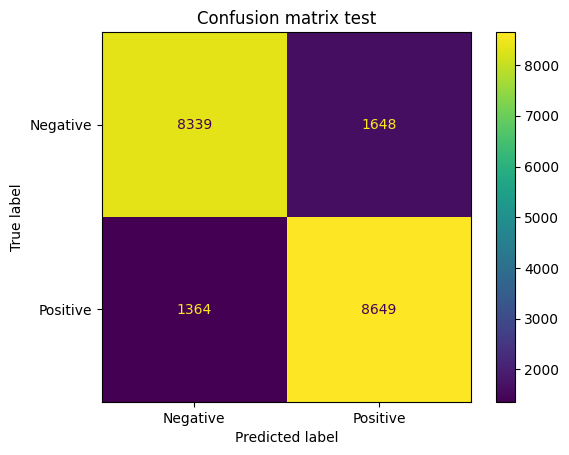

In [22]:
cm = confusion_matrix(actual_label,
                      pred_label,
                    )
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)
disp.plot()
plt.savefig("figs/cf.png")
plt.title("Confusion matrix test")
plt.show()

### 2.7 Testing the Model on Custom Examples

For fun, we test the model on some custom examples from IMDb.

In [23]:
# Function to classify a single review
def classify_review(review, model, tokenizer, pad_idx, cls_idx, max_length):
    # preprocess
    text = preprocess_text(review)
    text = f"[CLS]{text}"
    tokenized_review = tokenizer.encode(text)
    ids = tokenized_review.ids
    ids = ids[:max_length]
    length_needed_padding = max_length - len(ids)
    ids += [pad_idx] * length_needed_padding

    input_tensor = torch.tensor([ids])
    attention_mask = create_mask(input_tensor, pad_idx)

    model.eval()
    with torch.no_grad():
        prob = model(input_tensor, mask= attention_mask)
        sentiment = "Positive" if prob > 0.5 else "Negative"
    return sentiment, prob


In [30]:
reviews = {
    "The Matrix": "The timeless classic. This film doesn't age, it will be contemporary even in 2030 or 2040. Wachowski's best one, by far.",
    "Police Academy 4: Citizens on Patrol" : "There is not much good about the movie. The acting is bad. The writing is vomitous. The characters are so lame that you just want to hit them over the head with a Black and Decker toaster oven. I don't know what happened here, but this movie sucks.",
    "Neil breen, Fateful Findings" : "In all seriousness this movie is only enjoyable if you have a group of friends and a large amount of alcohol. From the low production value, the plot that goes nowhere, and the performances that make the movie what it is... Filler. Yes this movie has been Memed the to hell and back but I enjoyed it for what it was. Can't say if I would watch this movie alone sober though..",
    "Rupauls drag race" : "Groundbreaking TV and total eye-candy",
    "Twilight 1" : "Catherine Hardwicke, please put the camera down. You have absolutely no talent and yes, it does bother me that your daughter does get into every movie you direct. This could've been the greatest film of 2008 but your filthy little hands seem to have gotten on my favorite author. First of all, why in the world is Bella as pale as the vampires? I get that she doesn't tan, but she does still have a pulse according to the book. (Maybe you should read it. I mean, it is just based on the written version of Twilight.) I felt as if I had not read the book, I would have no idea what was going on in the movie, which in my opinion, isn't how a movie should present itself. UGH! GET ME A NEW DIRECTOR!!",
    "Custom review a1": "not good",
    "Custom review a2": "not not good",
    "Custom review a3": "not not not good",
    "Custom review b1": "not bad",
    "Custom review b2": "not not bad",
    "Custom review b3": "not not not bad"
}

for movie_name, review in reviews.items():
    print(f"Movie name = {movie_name}")
    sent, prob = classify_review(
        review = review,
        model = loaded_model, # model
        tokenizer=tokenizer,
        pad_idx=PAD_ID,
        cls_idx=None,
        max_length=MAX_LENGTH
    )
    print(f"Review is {sent} with sentiment probability {prob:.2}")
    print("\n")

Movie name = The Matrix
Review is Positive with sentiment probability 0.75


Movie name = Police Academy 4: Citizens on Patrol
Review is Negative with sentiment probability 0.0068


Movie name = Neil breen, Fateful Findings
Review is Negative with sentiment probability 0.17


Movie name = Rupauls drag race
Review is Positive with sentiment probability 0.98


Movie name = Twilight 1
Review is Negative with sentiment probability 0.2


Movie name = Custom review a1
Review is Positive with sentiment probability 0.91


Movie name = Custom review a2
Review is Negative with sentiment probability 0.48


Movie name = Custom review a3
Review is Negative with sentiment probability 0.16


Movie name = Custom review b1
Review is Negative with sentiment probability 0.0015


Movie name = Custom review b2
Review is Negative with sentiment probability 0.001


Movie name = Custom review b3
Review is Negative with sentiment probability 0.00087


